# DINO incremental → SAM3 point prompts → tracking

Incremental variant of `09_dino_sam_tracking.ipynb`: the DINO zoom detector runs
on every `KEYFRAME_STRIDE` frames (30 by default) on the ORIGINAL video (the
1024x576 proxy loses the small-dolphin signal, verified), and every candidate
that is not already covered by a tracked mask is added to the **live** SAM3
session as a new `obj_id` — so dolphins that appear mid-video get their own
masklets. The session itself stays on the 1024x576 proxy (VRAM). Each new object
is backfilled to the start of the video (reverse propagation) and then tracked
forward.

Mechanics: `add_prompt(points, obj_id)` → `add_tracker_new_points` (new tracker
state + action history); the next `propagate_in_video` becomes a *partial*
propagation for just the new obj_ids, merged with the cached masks of the
existing objects (`cached_frame_outputs`), so old tracks are never recomputed.
The direction is explicit: `"backward"` (fills 0..k-1) then `"forward"` (fills
k..end) — a single `"both"` call does NOT backfill new objects, because its
second pass degenerates into a cached fetch (SAM3 action history, see
`docs/src/fish_segmentation/sam3_utils.md`).

Caveats: `select_new_points` filters by score/solidity/area and by containment
in the masks tracked on that keyframe, but false positives (glints, waves) still
become tracks, like in 09. Every tracked object keeps a full-video mask in
`cached_frame_outputs`, so the session grows with objects x frames: `MAX_OBJECTS`
caps it (~0.3 GB of GPU + CPU mask per object over 475 frames at 1024x576).
Backfilled masks on frames before a dolphin actually appeared can be spurious.

Session order: `start_session` → `add_prompt` (points) → `propagate_in_video`
(partial, repeatedly) → `close_session` → `predictor.shutdown()`. The SAM3
checkpoint auto-downloads from the gated `facebook/sam3` repos: `load_env()` must
find `HF_TOKEN`.

In [1]:
%matplotlib inline
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from fish_segmentation.dinov3 import load_backbone, run_zoom_detector
from fish_segmentation.ingest import process_video
from fish_segmentation.paths import find_repo_root, load_env
from fish_segmentation.video_io import load_all_frames_rgb, load_frame_rgb

load_env()
ROOT = find_repo_root()

device = "cuda" if torch.cuda.is_available() else "cpu"
SESSION_FPS = 15        # proxy/session frame rate (DINO keyframes are mapped by time)
DINO_LONG_SIDE = 1024
DINO_RESOLUTION_SCALE = 4.0   # tuned on 4K originals (DINO runs on original frames)
ZONE_MERGE_GAP = 0.08
MIN_ZONE_FRACTION = 0.25
MIN_CONFIRMATIONS = 2   # keep only detections confirmed at >= 2 zoom levels
KEYFRAME_STRIDE = 30    # run DINO every 30 frames (2 s at 15 fps)
MAX_OBJECTS = 24        # cap on tracked masklets (masks grow with objects x frames)
MIN_SCORE = 0.5         # quality filters for new candidates (None disables one)
MIN_SOLIDITY = 0.25
MIN_AREA = None         # 'area' is in view pixels, not comparable across levels
MASK_MARGIN_PX = 4      # reject points this close to an already-tracked mask
DEDUPE_OVERLAP = 0.3    # bbox IoU above which two candidates are duplicates
print(device)

cuda


## 1. Original keyframes, session proxy and DINO backbone

DINO runs on ORIGINAL frames, not on the proxy: on the 1024x576 proxy the zoom
detector finds **zero** dolphins on the dataset footage (verified) because the
downscale destroys the small-object signal, while the 4K original yields the
expected detections at `resolution_scale=4.0`. Keyframe k of the session maps to
the original by time (`orig_index = k * orig_fps / SESSION_FPS`); detections are
relative `[0, 1]`, so they feed the proxy session unchanged.

The SAM3 session still runs on the 1024x576 proxy (per-frame mask cache at 4K
would OOM a 24 GB card). The loop reads one keyframe at a time with
`load_frame_rgb`; the full proxy is only loaded at the end for the overlay
video.

In [2]:
video_path = ROOT / "dataset" / "processed" / "20260813_213529_7f994a2f" / "video.mp4"
if not video_path.exists():
    video_path = ROOT / "data" / "test_media" / "dolphin_00.mp4"
print(f"Using video: {video_path}")

OUTPUTS = ROOT / "notebooks" / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
sam3_video_path = OUTPUTS / f"{video_path.parent.name}_{video_path.stem}_1024x576.mp4"
if not sam3_video_path.exists():
    process_video(
        input_path=str(video_path),
        output_path=str(sam3_video_path),
        target_width=1024,
        target_height=576,
        fps=SESSION_FPS,
    )

# DINO reads ORIGINAL frames (see section 1), so keyframe k maps by time; the
# session length and the overlay come from the proxy.
cap = cv2.VideoCapture(str(video_path))
orig_fps = cap.get(cv2.CAP_PROP_FPS) or SESSION_FPS
orig_n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

cap = cv2.VideoCapture(str(sam3_video_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(
    f"Original: {orig_n_frames} frames @ {orig_fps:.2f} fps | "
    f"session: {n_frames} frames @ {SESSION_FPS} fps"
)

Using video: /workspace/fish-segmentation/dataset/processed/20260813_213529_7f994a2f/video.mp4
Original: 475 frames @ 15.00 fps | session: 475 frames @ 15 fps


In [3]:
model, processor = load_backbone("facebook/dinov3-vitl16-pretrain-lvd1689m", device=device)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

## 2. SAM3 session

`start_session` loads the whole proxy into the predictor; point prompts are added
later, one `obj_id` per accepted detection, while the session stays alive.

In [4]:
from sam3.model_builder import build_sam3_video_predictor
from sam3.visualization_utils import save_masklet_video

from fish_segmentation.sam3_utils import (
    add_point_prompt,
    next_obj_id,
    propagate_in_video,
    select_new_points,
)

predictor = build_sam3_video_predictor(gpus_to_use=range(torch.cuda.device_count()))

response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=str(sam3_video_path),
    )
)
session_id = response["session_id"]

/workspace/fish-segmentation/sam3_src/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/workspace/fish-segmentation/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-09-20 20:47:41,600 19611 sam3_video_predictor.py: 120: using the following GPU IDs: [0]
INFO 2026-09-20 20:47:41,601 19611 sam3_video_predictor.py: 136: 


	*** START loading model on all ranks ***


INFO 2026-09-20 20:47:41,601 19611 sam3_video_predictor.py: 138: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-09-20 20:47:49,

## 3. Incremental loop: DINO every `KEYFRAME_STRIDE` frames

At every keyframe: run the zoom detector, drop candidates already covered by a
tracked mask (`select_new_points`), add the survivors as new `obj_id`s, then
propagate. From keyframe 1 on, propagate `"backward"` first (backfill to frame 0)
and then `"forward"` (to the end). All new points of a keyframe are added before
propagating, so one backward+forward pair covers every object added there.

  0%|          | 0/475 [00:00<?, ?it/s]

INFO 2026-09-20 20:49:20,624 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


k=   0:  5 DINO candidates,  5 new,  5 prompted,  5 tracked masklets


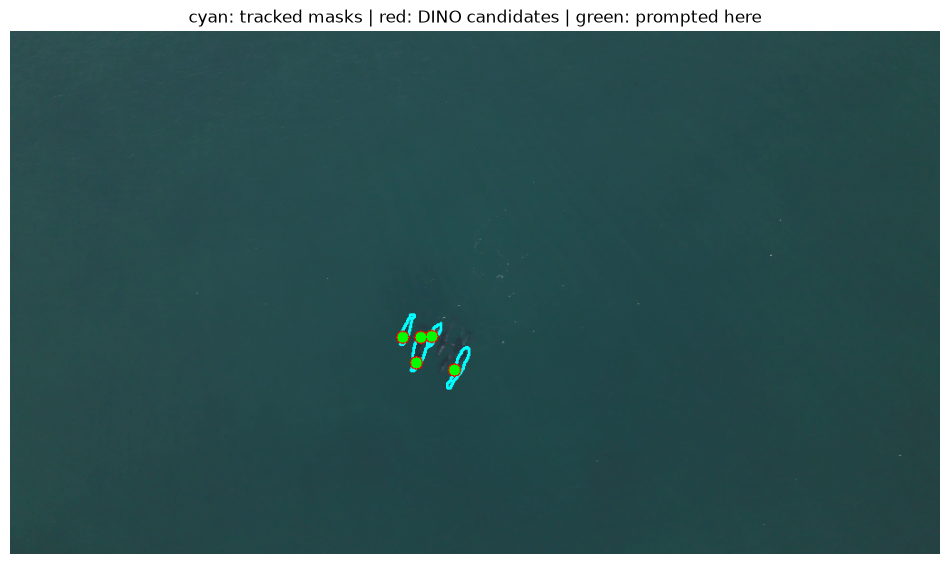

  0%|          | 0/30 [00:00<?, ?it/s]

INFO 2026-09-20 20:49:27,746 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


  0%|          | 0/445 [00:00<?, ?it/s]

INFO 2026-09-20 20:50:13,275 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


k=  30:  4 DINO candidates,  1 new,  1 prompted,  6 tracked masklets


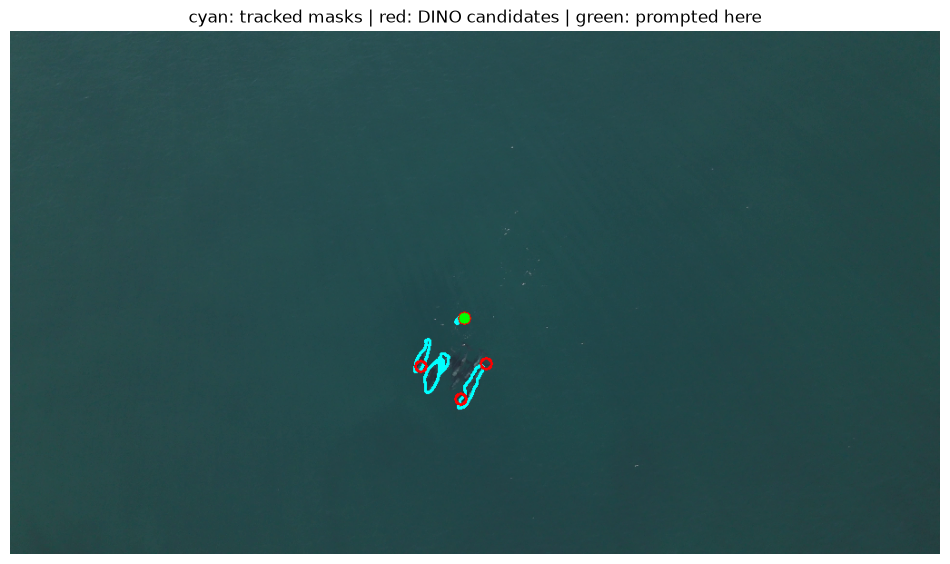

  0%|          | 0/60 [00:00<?, ?it/s]

INFO 2026-09-20 20:50:25,543 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


  0%|          | 0/415 [00:00<?, ?it/s]

INFO 2026-09-20 20:51:13,191 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


k=  60:  7 DINO candidates,  2 new,  2 prompted,  8 tracked masklets


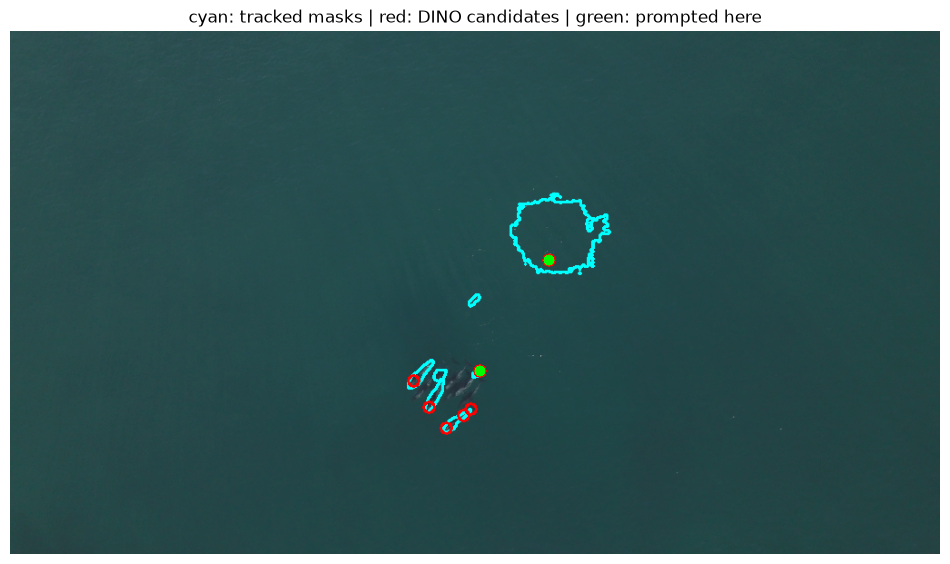

  0%|          | 0/90 [00:00<?, ?it/s]

INFO 2026-09-20 20:51:27,309 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


  0%|          | 0/385 [00:00<?, ?it/s]

INFO 2026-09-20 20:52:11,744 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


k=  90:  5 DINO candidates,  2 new,  2 prompted, 10 tracked masklets


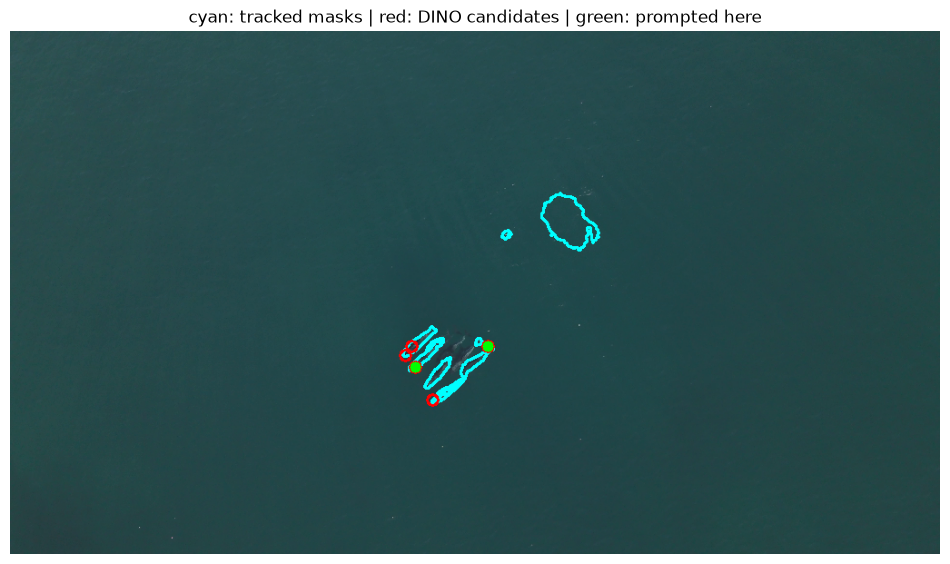

  0%|          | 0/120 [00:00<?, ?it/s]

INFO 2026-09-20 20:52:27,950 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


  0%|          | 0/355 [00:00<?, ?it/s]

INFO 2026-09-20 20:53:04,505 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


k= 120:  4 DINO candidates,  1 new,  1 prompted, 11 tracked masklets


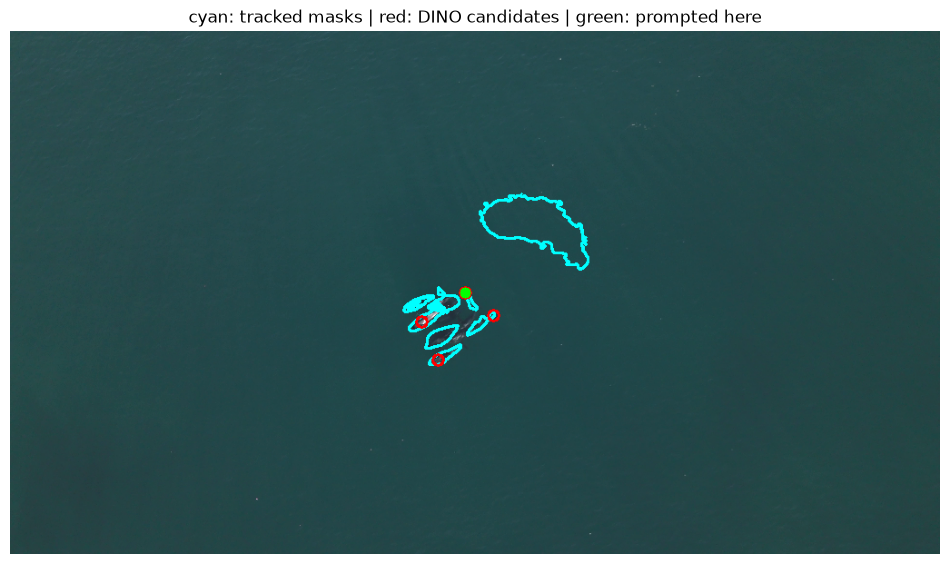

k= 150:  4 DINO candidates,  0 new,  0 prompted, 11 tracked masklets


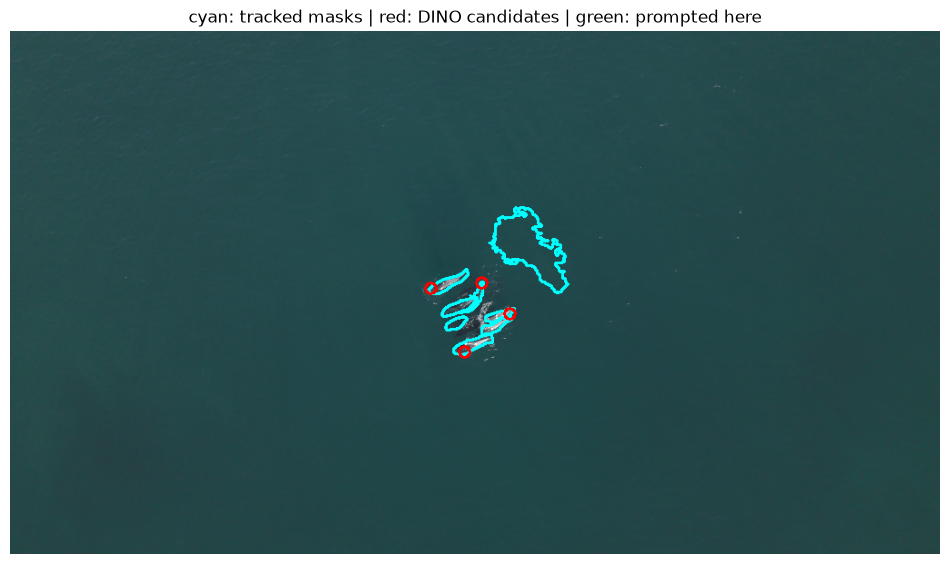

k= 180:  3 DINO candidates,  0 new,  0 prompted, 11 tracked masklets


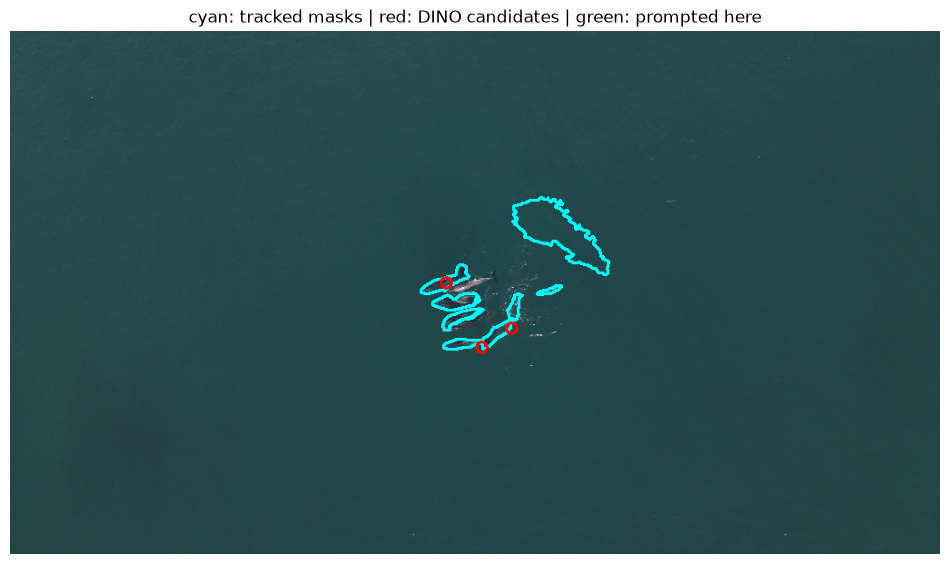

  0%|          | 0/210 [00:00<?, ?it/s]

INFO 2026-09-20 20:53:44,213 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


  0%|          | 0/265 [00:00<?, ?it/s]

INFO 2026-09-20 20:53:53,946 19611 sam3_base_predictor.py: 305: propagation ended in session 5491a8f1-bafc-404f-a63c-e95ed9eef413


OutOfMemoryError: CUDA out of memory. Tried to allocate 82.00 MiB. GPU 0 has a total capacity of 23.52 GiB of which 37.75 MiB is free. Including non-PyTorch memory, this process has 23.47 GiB memory in use. Of the allocated memory 21.77 GiB is allocated by PyTorch, and 1.24 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
keyframes = list(range(0, n_frames, KEYFRAME_STRIDE))
outputs_per_frame = {}
track_log = []
n_candidates = 0
n_new = 0

for k in keyframes:
    orig_index = int(round(k * orig_fps / SESSION_FPS))
    orig_index = min(max(orig_index, 0), orig_n_frames - 1)
    keyframe = load_frame_rgb(str(video_path), orig_index)
    if keyframe is None:
        print(f"k={k:4d}: original frame {orig_index} not readable, skipping")
        continue

    detections = run_zoom_detector(
        image=Image.fromarray(keyframe),
        model=model,
        processor=processor,
        long_side=DINO_LONG_SIDE,
        resolution_scale=DINO_RESOLUTION_SCALE,
        merge_gap=ZONE_MERGE_GAP,
        min_zone_fraction=MIN_ZONE_FRACTION,
        min_confirmations=MIN_CONFIRMATIONS,
    )
    new_points = select_new_points(
        detections,
        frame_outputs=outputs_per_frame.get(k),
        min_score=MIN_SCORE,
        min_solidity=MIN_SOLIDITY,
        min_area=MIN_AREA,
        mask_margin_px=MASK_MARGIN_PX,
        dedupe_overlap=DEDUPE_OVERLAP,
    )

    n_tracked = next_obj_id(outputs_per_frame)
    accepted = new_points[: max(0, MAX_OBJECTS - n_tracked)]
    for i, det in enumerate(accepted):
        add_point_prompt(
            predictor,
            session_id,
            frame_index=k,
            points=[[det["x"], det["y"]]],
            obj_id=n_tracked + i,
        )
        track_log.append(
            {
                "obj_id": n_tracked + i,
                "keyframe": k,
                "x": det["x"],
                "y": det["y"],
                "radius": det["radius"],
                "level": det["level"],
                "n_levels": det["n_levels"],
                "score_mean": det["score_mean"],
                "solidity": det["solidity"],
            }
        )

    if accepted:
        if k > 0:
            outputs_per_frame.update(
                propagate_in_video(
                    predictor,
                    session_id,
                    start_frame_index=k,
                    propagation_direction="backward",
                )
            )
        outputs_per_frame.update(
            propagate_in_video(
                predictor,
                session_id,
                start_frame_index=k,
                propagation_direction="forward",
            )
        )

    n_candidates += len(detections)
    n_new += len(accepted)
    print(
        f"k={k:4d}: {len(detections):2d} DINO candidates, "
        f"{len(new_points):2d} new, {len(accepted):2d} prompted, "
        f"{next_obj_id(outputs_per_frame):2d} tracked masklets"
    )

    # keyframe review: cyan = tracked masks, red = DINO candidates, green = prompted
    review = cv2.resize(keyframe, (1024, 576))  # 4K keyframe -> small review image
    frame_out = outputs_per_frame.get(k)
    if frame_out is not None:
        for mask in frame_out["out_binary_masks"]:
            contours, _ = cv2.findContours(
                mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            cv2.drawContours(review, contours, -1, (0, 255, 255), 2)
    for det in detections:
        cx, cy = int(det["x"] * review.shape[1]), int(det["y"] * review.shape[0])
        cv2.circle(review, (cx, cy), 6, (255, 0, 0), 2)
    for det in accepted:
        cx, cy = int(det["x"] * review.shape[1]), int(det["y"] * review.shape[0])
        cv2.circle(review, (cx, cy), 6, (0, 255, 0), -1)
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(review)
    ax.set_title("cyan: tracked masks | red: DINO candidates | green: prompted here")
    ax.axis("off")
    plt.show()

print(
    f"{len(track_log)} tracks prompted from {n_candidates} candidates over "
    f"{len(keyframes)} keyframes ({n_candidates - n_new} filtered out)"
)

## 4. Overlay video and track log

`outputs_per_frame` holds every frame after the last propagation (old objects
from their first full pass, new objects from their backfill/forward passes), so
`save_masklet_video` renders the complete incremental result. The JSON log lists
each track's discovery keyframe and detection metadata.

In [ ]:
stem = f"dino_sam_incremental_{video_path.parent.name}_{video_path.stem}"
track_video_path = OUTPUTS / f"{stem}.mp4"
track_log_path = OUTPUTS / f"{stem}_tracks.json"

if outputs_per_frame:
    proxy_frames = load_all_frames_rgb(str(sam3_video_path))
    save_masklet_video(
        video_frames=proxy_frames,
        outputs=outputs_per_frame,
        out_path=str(track_video_path),
        alpha=0.5,
        fps=15,
    )
    with open(track_log_path, "w") as f:
        json.dump(track_log, f, indent=2)
    print(track_video_path)
    print(track_log_path)
else:
    print("No tracks were prompted; nothing to render.")

In [ ]:
from IPython.display import Video

if track_video_path.exists():
    # relative src so JupyterLab serves it from notebooks/outputs without embedding it
    Video(f"outputs/{track_video_path.name}", embed=False, width=640)
else:
    print("No overlay video was written.")

## 5. Cleanup

`close_session` frees the session (and its per-frame mask cache);
`predictor.shutdown()` frees the process group.

In [ ]:
_ = predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

predictor.shutdown()

In [6]:
!nvidia-smi

Sun Sep 20 20:54:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:C2:00.0 Off |                  Off |
| 30%   43C    P8             29W /  450W |   24044MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----